###### **<span style="font-family: 'Palatino Linotype', serif;"> Iniciação à Pesquisa III </span>**

## **<span style="font-family: 'Palatino Linotype', serif;"> Parte I - Reconstrução e comparação das estratégias de ML </span>**

#### **<span style="font-family: 'Palatino Linotype', serif;"> Autor:</span>** <span style="font-family: 'Palatino Linotype', serif;"> Caio M. Leão Dantas</span> 
#### **<span style="font-family: 'Palatino Linotype', serif;"> Orientador:</span>** <span style="font-family: 'Palatino Linotype', serif;"> Leandro Oliveira Bortot</span> 
#### **<span style="font-family: 'Palatino Linotype', serif;"> Agradecimentos:</span>** <span style="font-family: 'Palatino Linotype', serif;"> Guilherme C. de A. Sobreira e Amauri D. Leal Júnior</span> 

___

In [1]:
from pathlib import Path
import os
import glob
import json
import random
import time
import copy
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)
from sklearn.linear_model import Ridge
from scipy.stats import spearmanr, pearsonr

import optuna
from optuna.samplers import TPESampler

from transformers import (
    AutoTokenizer,
    AutoModel,
    AutoModelForSequenceClassification
)

from rdkit import Chem, RDLogger
from rdkit.Chem import Descriptors, Lipinski, Crippen

RDLogger.DisableLog("rdApp.*")
warnings.filterwarnings("ignore")

Device: cpu
Results directory: C:\Users\caio24034\OneDrive - ILUM ESCOLA DE CIÊNCIA\CodingCodingCoding\IP\Dinâmica_Molecular\results_approach_I


In [ ]:
RESULTS_DIR = Path("./boltz_results_enamine_320/boltz_results_yamls_enamine_320/predictions/")
LIBRARY_CSV = Path("./Enamine_Essential_Fragment_Library_plated_320cmpds_20250824.csv")

OUTPUT_DIR = Path("./results_approach_I")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [ ]:
SEED = 8
TEST_SIZE = 0.15
VAL_SIZE_RELATIVE_TO_REMAINDER = 0.18

CHEMBERTA_NAME = "DeepChem/ChemBERTa-77M-MTR"
MAX_LENGTH = 128

EMBED_BATCH_SIZE = 32
ML_BATCH_SIZE = 32
FT_BATCH_SIZE = 16

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

TARGETS = {
    "probability": "affinity_probability_binary",
    "affinity": "affinity_pred_value",
}

print(f"Device: {DEVICE}")
print(f"Results directory: {OUTPUT_DIR.resolve()}")

In [2]:
def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed()

## Extração dos resultados do Boltz-2

Cada pasta corresponde a um ligante. O código abaixo procura os arquivos `confidence*.json` e `affinity*.json`, extrai as métricas disponíveis e associa posteriormente cada ID ao SMILES da biblioteca.

In [3]:
def extract_boltz_results(results_dir: Path) -> pd.DataFrame:
    folders = sorted([Path(p) for p in glob.glob(str(results_dir / "*/"))])

    rows = []

    for folder in folders:
        ligand_id = folder.name
        row = {"ID": ligand_id}

        confidence_files = sorted(folder.glob("confidence*.json"))
        affinity_files = sorted(folder.glob("affinity*.json"))

        if confidence_files:
            try:
                with open(confidence_files[0], "r", encoding="utf-8") as f:
                    data = json.load(f)
                row["confidence_score"] = data.get("confidence_score")
                row["ligand_iptm"] = data.get("ligand_iptm")
            except Exception as exc:
                print(f"[WARN] confidence: {ligand_id}: {exc}")

        if affinity_files:
            try:
                with open(affinity_files[0], "r", encoding="utf-8") as f:
                    data = json.load(f)

                for key in [
                    "affinity_pred_value",
                    "affinity_pred_value1",
                    "affinity_pred_value2",
                    "affinity_probability_binary",
                    "affinity_probability_binary1",
                    "affinity_probability_binary2",
                ]:
                    row[key] = data.get(key)

            except Exception as exc:
                print(f"[WARN] affinity: {ligand_id}: {exc}")

        rows.append(row)

    df_boltz = pd.DataFrame(rows)

    if df_boltz.empty:
        raise RuntimeError(
            f"Nenhuma pasta foi encontrada em {results_dir.resolve()}"
        )

    return df_boltz


df_boltz = extract_boltz_results(RESULTS_DIR)

print(f"Pastas encontradas: {len(df_boltz)}")
display(df_boltz.head())

Pastas encontradas: 315


,ID,confidence_score,ligand_iptm,affinity_pred_value,affinity_pred_value1,affinity_pred_value2,affinity_probability_binary,affinity_probability_binary1,affinity_probability_binary2
0,Z102767654,0.785149,0.935326,2.037855,2.499289,1.576422,0.117418,0.068145,0.166691
1,Z104378302,0.728699,0.853461,3.051652,2.737694,3.365611,0.201410,0.022944,0.379877
2,Z104472798,0.789956,0.891683,2.148874,1.920432,2.377316,0.150877,0.147405,0.154348
3,Z104473324,0.734588,0.861522,2.542624,2.556237,2.529011,0.133150,0.064655,0.201645
4,Z104473344,0.751538,0.833025,2.995334,2.890702,3.099966,0.140000,0.057958,0.222042


In [4]:
data = pd.read_csv(LIBRARY_CSV, sep=",", header=1)

required_library_cols = {"Catalog ID", "SMILES"}
missing = required_library_cols - set(data.columns)

if missing:
    raise ValueError(
        f"Colunas ausentes na biblioteca: {missing}. "
        f"Colunas disponíveis: {list(data.columns)}"
    )

df_smiles = (
    data[["Catalog ID", "SMILES"]]
    .rename(columns={"Catalog ID": "ID"})
    .copy()
)

df = df_boltz.merge(df_smiles, on="ID", how="inner")

# Remove duplicatas de ID, mantendo a primeira ocorrência
df = df.drop_duplicates(subset="ID").reset_index(drop=True)

print(f"Boltz-2 records: {len(df_boltz)}")
print(f"Library records: {len(df_smiles)}")
print(f"Merged unique ligands: {len(df)}")

display(df.head())

# ---------------------------
# Checagens de integridade
# ---------------------------
check_cols = [
    "SMILES",
    "confidence_score",
    "ligand_iptm",
    "affinity_pred_value",
    "affinity_probability_binary",
]

integrity = pd.DataFrame({
    "column": check_cols,
    "non_null": [df[c].notna().sum() for c in check_cols],
    "missing": [df[c].isna().sum() for c in check_cols],
})

display(integrity)

df.to_csv(OUTPUT_DIR / "reference_dataset.csv", index=False)

Boltz-2 records: 315
Library records: 320
Merged unique ligands: 315


,ID,confidence_score,ligand_iptm,affinity_pred_value,affinity_pred_value1,affinity_pred_value2,affinity_probability_binary,affinity_probability_binary1,affinity_probability_binary2,SMILES
0,Z102767654,0.785149,0.935326,2.037855,2.499289,1.576422,0.117418,0.068145,0.166691,CNCC=1C=CC(=CC1)N2CCCCC2
1,Z104378302,0.728699,0.853461,3.051652,2.737694,3.365611,0.201410,0.022944,0.379877,NC1=NC=2C=CC=CC2N1
2,Z104472798,0.789956,0.891683,2.148874,1.920432,2.377316,0.150877,0.147405,0.154348,NC1=NC=CS1
3,Z104473324,0.734588,0.861522,2.542624,2.556237,2.529011,0.133150,0.064655,0.201645,O=C(O)C=1C=CC(Cl)=CC1
4,Z104473344,0.751538,0.833025,2.995334,2.890702,3.099966,0.140000,0.057958,0.222042,O=C(O)CC1=CC=CS1


,column,non_null,missing
0,SMILES,315,0
1,confidence_score,315,0
2,ligand_iptm,315,0
3,affinity_pred_value,315,0
4,affinity_probability_binary,315,0


## Controle de qualidade químico

Antes de utilizar os dados no ML, cada SMILES é convertido para uma molécula RDKit, com moléculas inválidas sendo removidas da análise estrutural. Também verificamos duplicatas de SMILES e a quantidade de dados disponível para cada alvo.

In [5]:
# ============================================================
# 5. QC DOS SMILES
# ============================================================

def validate_smiles(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        return mol is not None
    except Exception:
        return False

df["smiles_valid"] = df["SMILES"].map(validate_smiles)

print(df["smiles_valid"].value_counts(dropna=False))

df = df[df["smiles_valid"]].copy()
df = df.drop(columns=["smiles_valid"]).reset_index(drop=True)

for target_name, target_col in TARGETS.items():
    valid_n = df[target_col].notna().sum()
    print(f"{target_name:>12}: {valid_n} valid labels")

smiles_valid
True    315
Name: count, dtype: int64
 probability: 315 valid labels
    affinity: 315 valid labels


## Exploração dos dados

Esta seção reproduz a análise de distribuição/correlação das métricas do Boltz-2. Ela é útil para mostrar que `confidence_score`, `affinity_probability_binary` e `affinity_pred_value` são variáveis distintas e não devem ser interpretadas como a mesma saída.

,count,mean,std,min,25%,50%,75%,max
confidence_score,315.0,0.761412,0.023797,0.681880,0.746507,0.762865,0.778403,0.816952
ligand_iptm,315.0,0.877660,0.051005,0.645449,0.859931,0.887886,0.912427,0.953897
affinity_pred_value,315.0,2.377140,0.598036,0.692822,2.021755,2.347685,2.816602,4.060464
affinity_probability_binary,315.0,0.209838,0.096134,0.053230,0.142048,0.189744,0.253285,0.593594


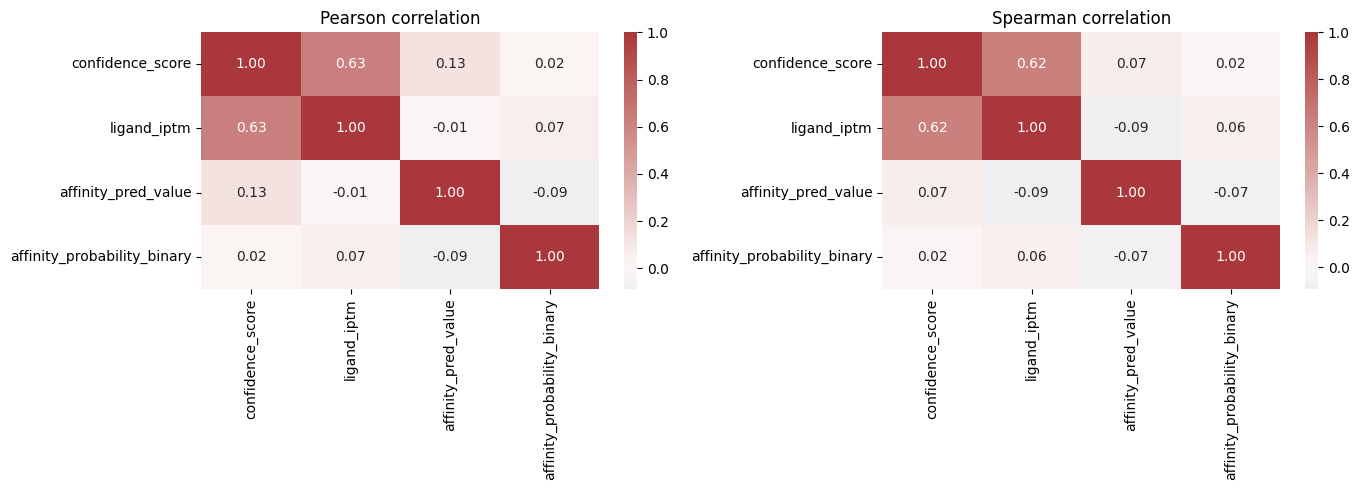

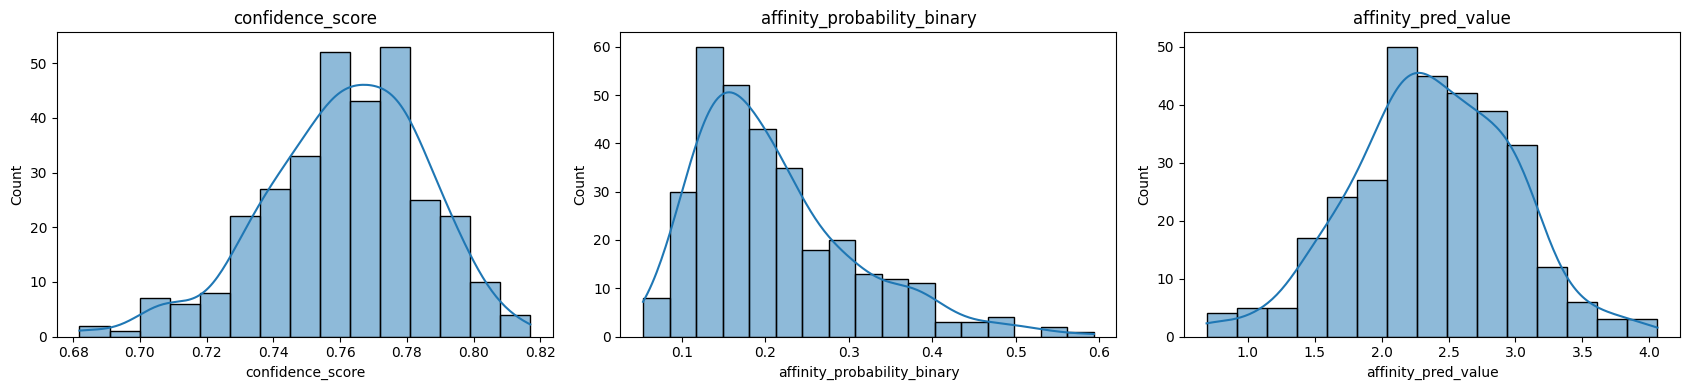

In [6]:
boltz_cols = [
    "confidence_score",
    "ligand_iptm",
    "affinity_pred_value",
    "affinity_probability_binary",
]

display(df[boltz_cols].describe().T)

corr_pearson = df[boltz_cols].corr(method="pearson")
corr_spearman = df[boltz_cols].corr(method="spearman")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(corr_pearson, annot=True, fmt=".2f", ax=axes[0], cmap="vlag", center=0)
axes[0].set_title("Pearson correlation")

sns.heatmap(corr_spearman, annot=True, fmt=".2f", ax=axes[1], cmap="vlag", center=0)
axes[1].set_title("Spearman correlation")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
sns.histplot(df["confidence_score"].dropna(), kde=True, ax=axes[0])
axes[0].set_title("confidence_score")

sns.histplot(df["affinity_probability_binary"].dropna(), kde=True, ax=axes[1])
axes[1].set_title("affinity_probability_binary")

sns.histplot(df["affinity_pred_value"].dropna(), kde=True, ax=axes[2])
axes[2].set_title("affinity_pred_value")

plt.tight_layout()
plt.show()

# Split de dados único

Para que a comparação entre representações seja justa, todas as abordagens usam **exatamente os mesmos índices de treino, validação e teste**. O *scaler*, quando necessário, é ajustado **somente no treino**, evitando *data leakage*. 

Nesta primeira reconstrução mantemos um random split para comparabilidade com o estudo anterior. Um scaffold split pode ser adicionado como análise de robustez depois.

In [7]:
df_model = df.dropna(
    subset=["SMILES", "affinity_probability_binary", "affinity_pred_value"]
).reset_index(drop=True)

all_indices = np.arange(len(df_model))

idx_train_val, idx_test = train_test_split(
    all_indices,
    test_size=TEST_SIZE,
    random_state=SEED,
    shuffle=True,
)

idx_train, idx_val = train_test_split(
    idx_train_val,
    test_size=VAL_SIZE_RELATIVE_TO_REMAINDER,
    random_state=SEED,
    shuffle=True,
)

print(f"Total: {len(df_model)}")
print(f"Train: {len(idx_train)}")
print(f"Validation: {len(idx_val)}")
print(f"Test: {len(idx_test)}")

np.save(OUTPUT_DIR / "idx_train.npy", idx_train)
np.save(OUTPUT_DIR / "idx_val.npy", idx_val)
np.save(OUTPUT_DIR / "idx_test.npy", idx_test)

Total: 315
Train: 218
Validation: 49
Test: 48


# Definição das métricas padronizadas

Como o objetivo final é **pré-screening**, não vamos olhar somente para `R²`.

Serão reportados:

- MAE;
- RMSE;
- R²;
- Pearson;
- Spearman.

Para a etapa posterior de screening, Spearman será especialmente importante porque mede preservação do ranking.

In [16]:
def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)

    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)

    pearson_r, pearson_p = pearsonr(y_true, y_pred)
    spearman_rho, spearman_p = spearmanr(y_true, y_pred)

    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2_score(y_true, y_pred),
        "Pearson_r": pearson_r,
        "Pearson_p": pearson_p,
        "Spearman_rho": spearman_rho,
        "Spearman_p": spearman_p,
    }


def evaluate_predictions(y_true, y_pred, target_name, method_name):
    metrics = regression_metrics(y_true, y_pred)
    metrics.update({
        "target": target_name,
        "method": method_name,
    })
    return metrics


def plot_predicted_vs_real(y_true, y_pred, title, x_label, y_label):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)

    lo = min(y_true.min(), y_pred.min())
    hi = max(y_true.max(), y_pred.max())

    plt.figure(figsize=(6.5, 6))
    plt.scatter(y_pred, y_true, alpha=0.75, edgecolor="black", linewidth=0.4)
    plt.plot([lo, hi], [lo, hi], "--", linewidth=1.5)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(title)
    plt.xlim(lo, hi)
    plt.ylim(lo, hi)
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

# Representação 1 — RDKit descriptors

Usaremos os mesmos cinco descritores empregados no estudo anterior:

- Molecular Weight;
- LogP;
- H-bond donors;
- H-bond acceptors;
- TPSA.

A diferença importante é que a normalização agora é ajustada apenas no conjunto de treino.

In [17]:
RDKit_COLUMNS = ["MolWt", "LogP", "HDonors", "HAcceptors", "TPSA"]

def compute_rdkit_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return [np.nan] * len(RDKit_COLUMNS)

    return [
        Descriptors.MolWt(mol),
        Crippen.MolLogP(mol),
        Lipinski.NumHDonors(mol),
        Lipinski.NumHAcceptors(mol),
        Descriptors.TPSA(mol),
    ]

rdkit_matrix = np.array(
    [compute_rdkit_descriptors(smi) for smi in df_model["SMILES"]]
)

print("RDKit matrix:", rdkit_matrix.shape)

rdkit_imputer = SimpleImputer(strategy="median")
rdkit_train_raw = rdkit_imputer.fit_transform(rdkit_matrix[idx_train])
rdkit_val_raw = rdkit_imputer.transform(rdkit_matrix[idx_val])
rdkit_test_raw = rdkit_imputer.transform(rdkit_matrix[idx_test])

rdkit_scaler = StandardScaler()
X_rdkit_train = rdkit_scaler.fit_transform(rdkit_train_raw)
X_rdkit_val = rdkit_scaler.transform(rdkit_val_raw)
X_rdkit_test = rdkit_scaler.transform(rdkit_test_raw)

print("Train:", X_rdkit_train.shape)

RDKit matrix: (315, 5)
Train: (218, 5)


# Representação 2 — ChemBERTa pré-treinado

O ChemBERTa é usado **sem fine-tuning** apenas para transformar o SMILES em uma representação latente de 384 dimensões. A média é feita usando `attention_mask`, evitando que tokens de padding contribuam para o embedding.

In [18]:
tokenizer = AutoTokenizer.from_pretrained(CHEMBERTA_NAME)
chemberta = AutoModel.from_pretrained(CHEMBERTA_NAME).to(DEVICE)
chemberta.eval()

def masked_mean_pool(last_hidden_state, attention_mask):
    mask = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
    summed = torch.sum(last_hidden_state * mask, dim=1)
    counts = torch.clamp(mask.sum(dim=1), min=1e-9)
    return summed / counts


def generate_chemberta_embeddings(smiles_list, batch_size=EMBED_BATCH_SIZE):
    encoded = tokenizer(
        list(smiles_list),
        padding=True,
        truncation=True,
        max_length=MAX_LENGTH,
        return_tensors="pt",
    )

    dataset = TensorDataset(
        encoded["input_ids"],
        encoded["attention_mask"],
    )

    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    embeddings = []

    with torch.no_grad():
        for ids_batch, mask_batch in loader:
            ids_batch = ids_batch.to(DEVICE)
            mask_batch = mask_batch.to(DEVICE)

            outputs = chemberta(
                input_ids=ids_batch,
                attention_mask=mask_batch,
            )

            pooled = masked_mean_pool(
                outputs.last_hidden_state,
                mask_batch,
            )

            embeddings.append(pooled.cpu())

    return torch.cat(embeddings, dim=0).numpy()


t0 = time.perf_counter()
chemberta_embeddings = generate_chemberta_embeddings(df_model["SMILES"])
t_chemberta_embedding = time.perf_counter() - t0

print("Embedding shape:", chemberta_embeddings.shape)
print(f"Embedding generation time: {t_chemberta_embedding:.3f} s")

Some weights of RobertaModel were not initialized from the model checkpoint at DeepChem/ChemBERTa-77M-MTR and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Embedding shape: (315, 384)
Embedding generation time: 0.448 s


In [19]:
embed_scaler = StandardScaler()

X_embed_train = embed_scaler.fit_transform(
    chemberta_embeddings[idx_train]
)

X_embed_val = embed_scaler.transform(
    chemberta_embeddings[idx_val]
)

X_embed_test = embed_scaler.transform(
    chemberta_embeddings[idx_test]
)

print(X_embed_train.shape)

(218, 384)


# Representação 3 — Fine-tuning do ChemBERTa

Aqui a representação não é congelada, e o próprio Transformer recebe o SMILES e seus parâmetros são ajustados para o target.

Como o dataset é pequeno, usamos:

- learning rate baixo;
- batch pequeno;
- early stopping;
- melhor checkpoint por validation loss.

Esta abordagem é mantida como experimento comparativo(!!!).

In [20]:
class ChemBERTaRegressor(nn.Module):
    def __init__(self, model_name, output_size=1):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        hidden_size = self.encoder.config.hidden_size
        self.head = nn.Linear(hidden_size, output_size)

    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        pooled = masked_mean_pool(
            outputs.last_hidden_state,
            attention_mask
        )

        return self.head(pooled)


def make_token_dataset(smiles_series, labels):
    encoded = tokenizer(
        list(smiles_series),
        padding=True,
        truncation=True,
        max_length=MAX_LENGTH,
        return_tensors="pt",
    )

    labels_tensor = torch.tensor(
        np.asarray(labels).reshape(-1, 1),
        dtype=torch.float32
    )

    return TensorDataset(
        encoded["input_ids"],
        encoded["attention_mask"],
        labels_tensor
    )


def train_finetuned_chemberta(
    train_smiles,
    y_train,
    val_smiles,
    y_val,
    epochs=30,
    lr=2e-5,
    weight_decay=1e-4,
    patience=5,
):
    model = ChemBERTaRegressor(CHEMBERTA_NAME).to(DEVICE)

    train_ds = make_token_dataset(train_smiles, y_train)
    val_ds = make_token_dataset(val_smiles, y_val)

    train_loader = DataLoader(
        train_ds,
        batch_size=FT_BATCH_SIZE,
        shuffle=True,
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=FT_BATCH_SIZE,
        shuffle=False,
    )

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay,
    )

    criterion = nn.MSELoss()

    best_val = np.inf
    best_state = None
    wait = 0

    history = {"train": [], "val": []}

    for epoch in range(epochs):
        set_seed(SEED + epoch)

        model.train()
        train_losses = []

        for ids, mask, labels in train_loader:
            ids = ids.to(DEVICE)
            mask = mask.to(DEVICE)
            labels = labels.to(DEVICE)

            optimizer.zero_grad()
            pred = model(ids, mask)
            loss = criterion(pred, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            train_losses.append(loss.item())

        model.eval()
        val_losses = []

        with torch.no_grad():
            for ids, mask, labels in val_loader:
                ids = ids.to(DEVICE)
                mask = mask.to(DEVICE)
                labels = labels.to(DEVICE)

                pred = model(ids, mask)
                loss = criterion(pred, labels)
                val_losses.append(loss.item())

        train_loss = float(np.mean(train_losses))
        val_loss = float(np.mean(val_losses))

        history["train"].append(train_loss)
        history["val"].append(val_loss)

        if val_loss < best_val:
            best_val = val_loss
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1

        if (epoch + 1) % 5 == 0:
            print(
                f"Epoch {epoch+1:02d}/{epochs} | "
                f"train={train_loss:.4f} | val={val_loss:.4f}"
            )

        if wait >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history


def predict_finetuned_model(model, smiles_series):
    encoded = tokenizer(
        list(smiles_series),
        padding=True,
        truncation=True,
        max_length=MAX_LENGTH,
        return_tensors="pt",
    )

    ds = TensorDataset(
        encoded["input_ids"],
        encoded["attention_mask"],
    )

    loader = DataLoader(ds, batch_size=FT_BATCH_SIZE, shuffle=False)

    preds = []

    model.eval()

    with torch.no_grad():
        for ids, mask in loader:
            ids = ids.to(DEVICE)
            mask = mask.to(DEVICE)
            preds.append(model(ids, mask).cpu())

    return torch.cat(preds).numpy().reshape(-1)

# Modelo comum de comparação — FC-NN

Para a comparação inicial das representações, usamos a mesma arquitetura simples de MLP/FC-NN.

Isso responde de forma mais limpa:

> **qual representação fornece a melhor informação para o mesmo modelo preditivo?**

Depois, somente a abordagem vencedora será otimizada com Optuna.

In [21]:
class SimpleMLP(nn.Module):
    def __init__(self, input_dim, output_dim=1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.GELU(),
            nn.Dropout(0.20),
            nn.Linear(128, 64),
            nn.GELU(),
            nn.Dropout(0.20),
            nn.Linear(64, output_dim),
        )

    def forward(self, x):
        return self.net(x)


def train_mlp_fixed_architecture(
    X_train,
    y_train,
    X_val,
    y_val,
    epochs=300,
    lr=1e-3,
    weight_decay=1e-5,
    patience=30,
):
    X_train_t = torch.tensor(X_train, dtype=torch.float32)
    y_train_t = torch.tensor(np.asarray(y_train).reshape(-1, 1), dtype=torch.float32)

    X_val_t = torch.tensor(X_val, dtype=torch.float32)
    y_val_t = torch.tensor(np.asarray(y_val).reshape(-1, 1), dtype=torch.float32)

    train_loader = DataLoader(
        TensorDataset(X_train_t, y_train_t),
        batch_size=ML_BATCH_SIZE,
        shuffle=True,
    )

    model = SimpleMLP(X_train.shape[1]).to(DEVICE)
    criterion = nn.MSELoss()

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay,
    )

    best_val = np.inf
    best_state = None
    wait = 0

    history = {"train": [], "val": []}

    for epoch in range(epochs):
        model.train()
        losses = []

        for xb, yb in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            optimizer.step()

            losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            val_pred = model(X_val_t.to(DEVICE))
            val_loss = criterion(
                val_pred,
                y_val_t.to(DEVICE)
            ).item()

        train_loss = float(np.mean(losses))
        history["train"].append(train_loss)
        history["val"].append(val_loss)

        if val_loss < best_val:
            best_val = val_loss
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1

        if wait >= patience:
            break

    model.load_state_dict(best_state)

    return model, history


def predict_mlp(model, X):
    X_t = torch.tensor(X, dtype=torch.float32)

    loader = DataLoader(
        TensorDataset(X_t),
        batch_size=ML_BATCH_SIZE,
        shuffle=False,
    )

    preds = []

    model.eval()
    with torch.no_grad():
        for (xb,) in loader:
            preds.append(model(xb.to(DEVICE)).cpu())

    return torch.cat(preds).numpy().reshape(-1)

# Baseline com informações do próprio Boltz-2

Este baseline funciona como **controle positivo metodológico**.

Ele não será usado posteriormente no screening de uma biblioteca nova, pois uma biblioteca desconhecida não terá esses valores antes do Boltz-2.

Para evitar uma forma trivial de leakage, o target não entra como feature direta.

In [22]:
# Para o target probability, usamos confidence + ligand_iptm + affinity_pred_value.
# Para o target affinity, usamos confidence + ligand_iptm + probability.

BOLTZ_FEATURES_BY_TARGET = {
    "probability": [
        "confidence_score",
        "ligand_iptm",
        "affinity_pred_value",
    ],
    "affinity": [
        "confidence_score",
        "ligand_iptm",
        "affinity_probability_binary",
    ],
}

def prepare_boltz_features(target_key):
    cols = BOLTZ_FEATURES_BY_TARGET[target_key]

    matrix = df_model[cols].values.astype(float)

    imputer = SimpleImputer(strategy="median")
    train_raw = imputer.fit_transform(matrix[idx_train])
    val_raw = imputer.transform(matrix[idx_val])
    test_raw = imputer.transform(matrix[idx_test])

    scaler = StandardScaler()

    X_train = scaler.fit_transform(train_raw)
    X_val = scaler.transform(val_raw)
    X_test = scaler.transform(test_raw)

    return X_train, X_val, X_test, imputer, scaler

# Comparação inicial — todas as representações

Para cada target:

- RDKit → FC-NN;
- ChemBERTa frozen → FC-NN;
- Boltz features → FC-NN;
- ChemBERTa fine-tuning.

Todas são avaliadas no **mesmo conjunto de teste**.

A saída principal será `comparison_results.csv`.

In [23]:
comparison_rows = []
comparison_predictions = {}

for target_key, target_col in TARGETS.items():
    print("\n" + "=" * 70)
    print(f"TARGET: {target_key} ({target_col})")
    print("=" * 70)

    y = df_model[target_col].values.astype(float)

    y_train = y[idx_train]
    y_val = y[idx_val]
    y_test = y[idx_test]

    # --------------------------------------------------------
    # RDKit
    # --------------------------------------------------------
    print("\n[RDKit]")
    rdkit_model, rdkit_history = train_mlp_fixed_architecture(
        X_rdkit_train,
        y_train,
        X_rdkit_val,
        y_val,
    )
    pred_rdkit = predict_mlp(rdkit_model, X_rdkit_test)

    metrics = evaluate_predictions(
        y_test, pred_rdkit, target_key, "RDKit"
    )
    comparison_rows.append(metrics)
    comparison_predictions[(target_key, "RDKit")] = (y_test, pred_rdkit)

    # --------------------------------------------------------
    # ChemBERTa frozen
    # --------------------------------------------------------
    print("[ChemBERTa frozen]")
    embed_model, embed_history = train_mlp_fixed_architecture(
        X_embed_train,
        y_train,
        X_embed_val,
        y_val,
    )
    pred_embed = predict_mlp(embed_model, X_embed_test)

    metrics = evaluate_predictions(
        y_test, pred_embed, target_key, "ChemBERTa_frozen"
    )
    comparison_rows.append(metrics)
    comparison_predictions[(target_key, "ChemBERTa_frozen")] = (y_test, pred_embed)

    # --------------------------------------------------------
    # Boltz features
    # --------------------------------------------------------
    print("[Boltz features]")
    X_boltz_train, X_boltz_val, X_boltz_test, _, _ = prepare_boltz_features(target_key)

    boltz_model, boltz_history = train_mlp_fixed_architecture(
        X_boltz_train,
        y_train,
        X_boltz_val,
        y_val,
    )
    pred_boltz = predict_mlp(boltz_model, X_boltz_test)

    metrics = evaluate_predictions(
        y_test, pred_boltz, target_key, "Boltz_features_baseline"
    )
    comparison_rows.append(metrics)
    comparison_predictions[(target_key, "Boltz_features_baseline")] = (y_test, pred_boltz)

    # --------------------------------------------------------
    # Fine-tuning
    # --------------------------------------------------------
    print("[ChemBERTa fine-tuning]")
    ft_model, ft_history = train_finetuned_chemberta(
        df_model.loc[idx_train, "SMILES"],
        y_train,
        df_model.loc[idx_val, "SMILES"],
        y_val,
    )

    pred_ft = predict_finetuned_model(
        ft_model,
        df_model.loc[idx_test, "SMILES"]
    )

    metrics = evaluate_predictions(
        y_test, pred_ft, target_key, "ChemBERTa_finetuned"
    )
    comparison_rows.append(metrics)
    comparison_predictions[(target_key, "ChemBERTa_finetuned")] = (y_test, pred_ft)

comparison_df = pd.DataFrame(comparison_rows)

comparison_df = comparison_df.sort_values(
    ["target", "RMSE"],
    ascending=[True, True]
).reset_index(drop=True)

display(comparison_df)

comparison_df.to_csv(
    OUTPUT_DIR / "comparison_results.csv",
    index=False
)


TARGET: probability (affinity_probability_binary)

[RDKit]
[ChemBERTa frozen]
[Boltz features]
[ChemBERTa fine-tuning]


Some weights of RobertaModel were not initialized from the model checkpoint at DeepChem/ChemBERTa-77M-MTR and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 05/30 | train=0.0127 | val=0.0136
Epoch 10/30 | train=0.0088 | val=0.0111
Epoch 15/30 | train=0.0083 | val=0.0094
Epoch 20/30 | train=0.0068 | val=0.0088
Epoch 25/30 | train=0.0065 | val=0.0083
Early stopping at epoch 28

TARGET: affinity (affinity_pred_value)

[RDKit]
[ChemBERTa frozen]
[Boltz features]
[ChemBERTa fine-tuning]


Some weights of RobertaModel were not initialized from the model checkpoint at DeepChem/ChemBERTa-77M-MTR and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 05/30 | train=3.1001 | val=2.5078
Epoch 10/30 | train=0.2841 | val=0.3477
Early stopping at epoch 14


,MAE,MSE,RMSE,R2,Pearson_r,Pearson_p,Spearman_rho,Spearman_p,target,method
0,0.381466,0.227470,0.476938,0.105095,0.361794,0.011513,0.336409,0.019394,affinity,RDKit
1,0.413671,0.282133,0.531162,-0.109958,0.129035,0.382075,0.030612,0.836365,affinity,Boltz_features_baseline
2,0.450058,0.342173,0.584956,-0.346168,0.282653,0.051588,0.245766,0.092226,affinity,ChemBERTa_frozen
3,0.485292,0.380692,0.617003,-0.497709,0.392603,0.005778,0.388081,0.006419,affinity,ChemBERTa_finetuned
4,0.051709,0.004374,0.066134,0.193520,0.583138,0.000014,0.635041,0.000001,probability,ChemBERTa_frozen
5,0.050411,0.004678,0.068399,0.137341,0.414818,0.003373,0.430200,0.002274,probability,RDKit
6,0.056637,0.005435,0.073725,-0.002237,0.609705,0.000004,0.614850,0.000003,probability,ChemBERTa_finetuned
7,0.063765,0.006416,0.080102,-0.183143,0.033395,0.821722,0.053409,0.718451,probability,Boltz_features_baseline


# Visualização da comparação

A tabela é o resultado principal da etapa de engenharia de features.

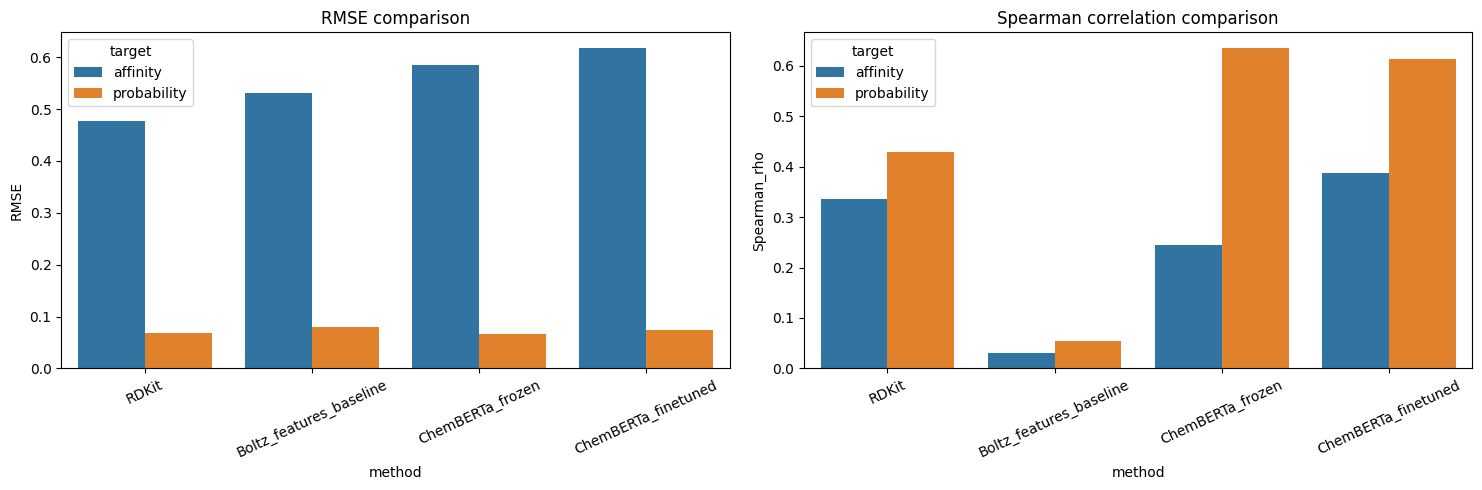

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(
    data=comparison_df,
    x="method",
    y="RMSE",
    hue="target",
    ax=axes[0]
)
axes[0].set_title("RMSE comparison")
axes[0].tick_params(axis="x", rotation=25)

sns.barplot(
    data=comparison_df,
    x="method",
    y="Spearman_rho",
    hue="target",
    ax=axes[1]
)
axes[1].set_title("Spearman correlation comparison")
axes[1].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

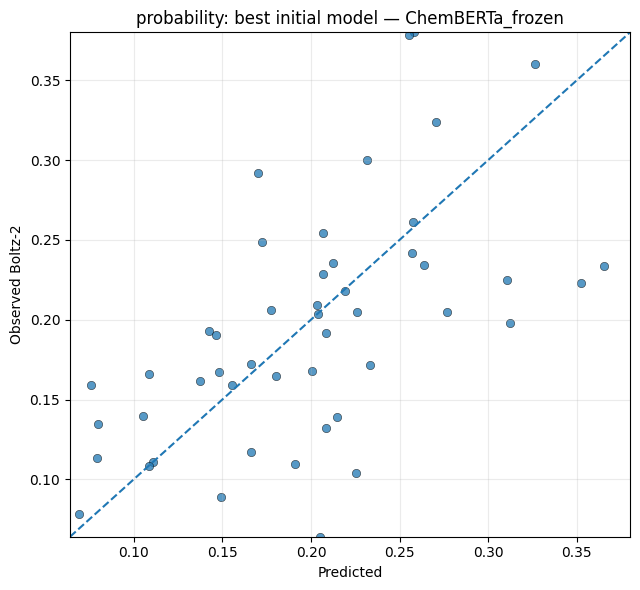

                 method      MAE     RMSE        R2  Pearson_r  Spearman_rho
       ChemBERTa_frozen 0.051709 0.066134  0.193520   0.583138      0.635041
                  RDKit 0.050411 0.068399  0.137341   0.414818      0.430200
    ChemBERTa_finetuned 0.056637 0.073725 -0.002237   0.609705      0.614850
Boltz_features_baseline 0.063765 0.080102 -0.183143   0.033395      0.053409


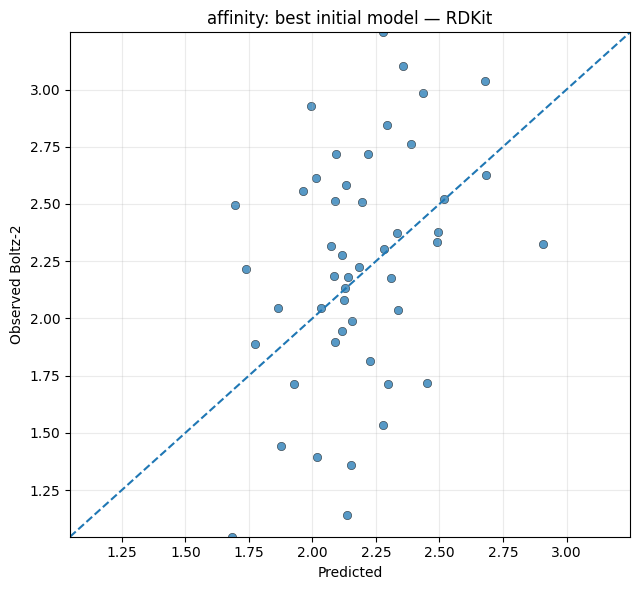

                 method      MAE     RMSE        R2  Pearson_r  Spearman_rho
                  RDKit 0.381466 0.476938  0.105095   0.361794      0.336409
Boltz_features_baseline 0.413671 0.531162 -0.109958   0.129035      0.030612
       ChemBERTa_frozen 0.450058 0.584956 -0.346168   0.282653      0.245766
    ChemBERTa_finetuned 0.485292 0.617003 -0.497709   0.392603      0.388081


In [25]:
for target_key in TARGETS:
    subset = comparison_df[
        comparison_df["target"] == target_key
    ].copy()

    best_method = subset.iloc[0]["method"]

    y_true, y_pred = comparison_predictions[(target_key, best_method)]

    target_label = TARGETS[target_key]

    plot_predicted_vs_real(
        y_true,
        y_pred,
        title=f"{target_key}: best initial model — {best_method}",
        x_label="Predicted",
        y_label="Observed Boltz-2",
    )

    print(
        subset[
            ["method", "MAE", "RMSE", "R2", "Pearson_r", "Spearman_rho"]
        ].to_string(index=False)
    )

# Seleção da melhor representação

A seleção é feita separadamente para os dois targets. Como o projeto é voltado para pré-screening, `affinity_probability_binary` terá prioridade operacional, e o modelo vencedor será então submetido à otimização de hiperparâmetros.

In [26]:
# ============================================================
# 16. SELEÇÃO INICIAL
# ============================================================

best_initial_by_target = (
    comparison_df
    .sort_values(["target", "RMSE"])
    .groupby("target", as_index=False)
    .first()
)

display(best_initial_by_target)

,target,MAE,MSE,RMSE,R2,Pearson_r,Pearson_p,Spearman_rho,Spearman_p,method
0,affinity,0.381466,0.227470,0.476938,0.105095,0.361794,0.011513,0.336409,0.019394,RDKit
1,probability,0.051709,0.004374,0.066134,0.193520,0.583138,0.000014,0.635041,0.000001,ChemBERTa_frozen


# Otimização da FC-NN com Optuna

Agora que a representação foi comparada sob condições padronizadas, usamos Optuna apenas para otimizar a FC-NN da representação vencedora.

Critério:
\[
\min MSE_{validation}
\]

Parâmetros explorados:
- número de camadas;
- unidades por camada;
- ativação;
- dropout;
- learning rate;
- weight decay.

O `MedianPruner` permite descartar configurações pouco promissoras.

In [27]:
screening_candidates = [
    "RDKit",
    "ChemBERTa_frozen",
]

probability_results = comparison_df[
    (comparison_df["target"] == "probability") &
    (comparison_df["method"].isin(screening_candidates))
].copy()

# Critério principal: RMSE menor.
# Em caso de empate próximo, o ranking (Spearman) pode ser usado como critério secundário durante a interpretação.
probability_results = probability_results.sort_values(
    ["RMSE", "Spearman_rho"],
    ascending=[True, False]
)

winner_probability = probability_results.iloc[0]["method"]

print("Winner for future screening:", winner_probability)
display(
    probability_results[
        ["method", "MAE", "RMSE", "R2", "Pearson_r", "Spearman_rho"]
    ]
)

FEATURE_MAP = {
    "RDKit": (X_rdkit_train, X_rdkit_val, X_rdkit_test),
    "ChemBERTa_frozen": (X_embed_train, X_embed_val, X_embed_test),
}

Xw_train, Xw_val, Xw_test = FEATURE_MAP[winner_probability]

y_prob = df_model["affinity_probability_binary"].values.astype(float)

yw_train = y_prob[idx_train]
yw_val = y_prob[idx_val]
yw_test = y_prob[idx_test]

input_size = Xw_train.shape[1]
output_size = 1

print("Input size:", input_size)


Winner for future screening: ChemBERTa_frozen


,method,MAE,RMSE,R2,Pearson_r,Spearman_rho
4,ChemBERTa_frozen,0.051709,0.066134,0.193520,0.583138,0.635041
5,RDKit,0.050411,0.068399,0.137341,0.414818,0.430200


Input size: 384


In [28]:
class MLPRegressor(nn.Module):
    def __init__(self, layer_sizes, activations, dropouts, output_size=1):
        super().__init__()

        layers = []
        in_features = layer_sizes[0]

        activation_map = {
            "ReLU": nn.ReLU,
            "LeakyReLU": nn.LeakyReLU,
            "GELU": nn.GELU,
            "Tanh": nn.Tanh,
            "SiLU": nn.SiLU,
        }

        for hidden_size, act_name, dropout in zip(
            layer_sizes[1:],
            activations,
            dropouts
        ):
            layers.append(nn.Linear(in_features, hidden_size))
            layers.append(activation_map[act_name]())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            in_features = hidden_size

        layers.append(nn.Linear(in_features, output_size))

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


def train_trial_model(
    trial,
    X_train,
    y_train,
    X_val,
    y_val,
    epochs=150,
):
    n_layers = trial.suggest_int("n_layers", 1, 4)

    hidden_sizes = []
    activations = []
    dropouts = []

    for i in range(n_layers):
        hidden_sizes.append(
            trial.suggest_categorical(
                f"units_{i}",
                [32, 64, 128, 256]
            )
        )
        activations.append(
            trial.suggest_categorical(
                f"activation_{i}",
                ["ReLU", "GELU", "SiLU", "Tanh"]
            )
        )
        dropouts.append(
            trial.suggest_float(
                f"dropout_{i}",
                0.0,
                0.4
            )
        )

    layer_sizes = [X_train.shape[1]] + hidden_sizes

    model = MLPRegressor(
        layer_sizes,
        activations,
        dropouts,
        output_size=1
    ).to(DEVICE)

    lr = trial.suggest_float(
        "lr",
        1e-4,
        5e-3,
        log=True
    )
    weight_decay = trial.suggest_float(
        "weight_decay",
        1e-7,
        1e-3,
        log=True
    )

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )
    criterion = nn.MSELoss()

    Xtr = torch.tensor(X_train, dtype=torch.float32)
    ytr = torch.tensor(y_train.reshape(-1, 1), dtype=torch.float32)

    Xv = torch.tensor(X_val, dtype=torch.float32)
    yv = torch.tensor(y_val.reshape(-1, 1), dtype=torch.float32)

    loader = DataLoader(
        TensorDataset(Xtr, ytr),
        batch_size=ML_BATCH_SIZE,
        shuffle=True
    )

    best_val = np.inf
    patience = 20
    wait = 0

    for epoch in range(epochs):
        model.train()

        for xb, yb in loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_loss = criterion(
                model(Xv.to(DEVICE)),
                yv.to(DEVICE)
            ).item()

        trial.report(val_loss, epoch)

        if trial.should_prune():
            raise optuna.TrialPruned()

        if val_loss < best_val:
            best_val = val_loss
            wait = 0
        else:
            wait += 1

        if wait >= patience:
            break

    return best_val


def objective(trial):
    set_seed(SEED)

    return train_trial_model(
        trial,
        Xw_train,
        yw_train,
        Xw_val,
        yw_val
    )

In [29]:
OPTUNA_DB = f"sqlite:///{(OUTPUT_DIR / 'optuna_screening.db').as_posix()}"
STUDY_NAME = "approach_I_screening_probability"

study = optuna.create_study(
    study_name=STUDY_NAME,
    storage=OPTUNA_DB,
    direction="minimize",
    sampler=TPESampler(seed=SEED),
    pruner=optuna.pruners.MedianPruner(),
    load_if_exists=True,
)

N_TRIALS = 50

study.optimize(
    objective,
    n_trials=N_TRIALS,
    show_progress_bar=True
)

print("Best validation MSE:", study.best_value)
print("Best parameters:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

[I 2026-09-11 18:04:36,883] A new study created in RDB with name: approach_I_screening_probability


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-09-11 18:04:41,480] Trial 0 finished with value: 0.008165407925844193 and parameters: {'n_layers': 4, 'units_0': 32, 'activation_0': 'Tanh', 'dropout_0': 0.191356718320961, 'units_1': 128, 'activation_1': 'Tanh', 'dropout_1': 0.13350961820426815, 'units_2': 128, 'activation_2': 'Tanh', 'dropout_2': 0.3584580019522541, 'units_3': 64, 'activation_3': 'SiLU', 'dropout_3': 0.17299037311616636, 'lr': 0.00028771964233928737, 'weight_decay': 0.00016003815843960973}. Best is trial 0 with value: 0.008165407925844193.
[I 2026-09-11 18:04:44,737] Trial 1 finished with value: 0.008701658807694912 and parameters: {'n_layers': 3, 'units_0': 128, 'activation_0': 'SiLU', 'dropout_0': 0.01556491905692874, 'units_1': 128, 'activation_1': 'Tanh', 'dropout_1': 0.37586041577646995, 'units_2': 32, 'activation_2': 'ReLU', 'dropout_2': 0.17392649135343552, 'lr': 0.0005408722946272178, 'weight_decay': 5.540318628275503e-07}. Best is trial 0 with value: 0.008165407925844193.
[I 2026-09-11 18:04:49,449] 

# Treinamento final do melhor modelo

Aqui reconstruímos a arquitetura indicada pelo Optuna e treinamos com early stopping.

In [30]:
def build_best_mlp(best_params, input_dim):
    n_layers = best_params["n_layers"]

    hidden_sizes = [
        best_params[f"units_{i}"]
        for i in range(n_layers)
    ]

    activations = [
        best_params[f"activation_{i}"]
        for i in range(n_layers)
    ]

    dropouts = [
        best_params[f"dropout_{i}"]
        for i in range(n_layers)
    ]

    return MLPRegressor(
        [input_dim] + hidden_sizes,
        activations,
        dropouts,
        output_size=1
    ).to(DEVICE)


best_model = build_best_mlp(
    study.best_params,
    Xw_train.shape[1]
)

optimizer = torch.optim.AdamW(
    best_model.parameters(),
    lr=study.best_params["lr"],
    weight_decay=study.best_params["weight_decay"]
)

criterion = nn.MSELoss()

Xtr = torch.tensor(Xw_train, dtype=torch.float32)
ytr = torch.tensor(yw_train.reshape(-1, 1), dtype=torch.float32)

Xv = torch.tensor(Xw_val, dtype=torch.float32)
yv = torch.tensor(yw_val.reshape(-1, 1), dtype=torch.float32)

train_loader = DataLoader(
    TensorDataset(Xtr, ytr),
    batch_size=ML_BATCH_SIZE,
    shuffle=True
)

best_state = None
best_val = np.inf
wait = 0
patience = 50

history_final = {
    "train": [],
    "val": [],
}

for epoch in range(1000):
    best_model.train()
    train_losses = []

    for xb, yb in train_loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        optimizer.zero_grad()
        pred = best_model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

    avg_train = float(np.mean(train_losses))

    best_model.eval()

    with torch.no_grad():
        val_pred = best_model(Xv.to(DEVICE))
        avg_val = criterion(
            val_pred,
            yv.to(DEVICE)
        ).item()

    history_final["train"].append(avg_train)
    history_final["val"].append(avg_val)

    if avg_val < best_val:
        best_val = avg_val
        best_state = copy.deepcopy(best_model.state_dict())
        wait = 0
    else:
        wait += 1

    if (epoch + 1) % 20 == 0:
        print(
            f"Epoch {epoch+1:04d} | "
            f"train={avg_train:.5f} | val={avg_val:.5f}"
        )

    if wait >= patience:
        print(f"Early stopping at epoch {epoch+1}")
        break

best_model.load_state_dict(best_state)

pred_final = predict_mlp(best_model, Xw_test)

final_metrics = evaluate_predictions(
    yw_test,
    pred_final,
    "probability",
    f"FINAL_{winner_probability}"
)

print(pd.Series(final_metrics))

Epoch 0020 | train=0.00297 | val=0.00795
Epoch 0040 | train=0.00183 | val=0.00919
Early stopping at epoch 58
MAE                           0.046656
MSE                           0.003917
RMSE                          0.062586
R2                            0.277722
Pearson_r                      0.59666
Pearson_p                     0.000008
Spearman_rho                  0.670213
Spearman_p                         0.0
target                     probability
method          FINAL_ChemBERTa_frozen
dtype: object


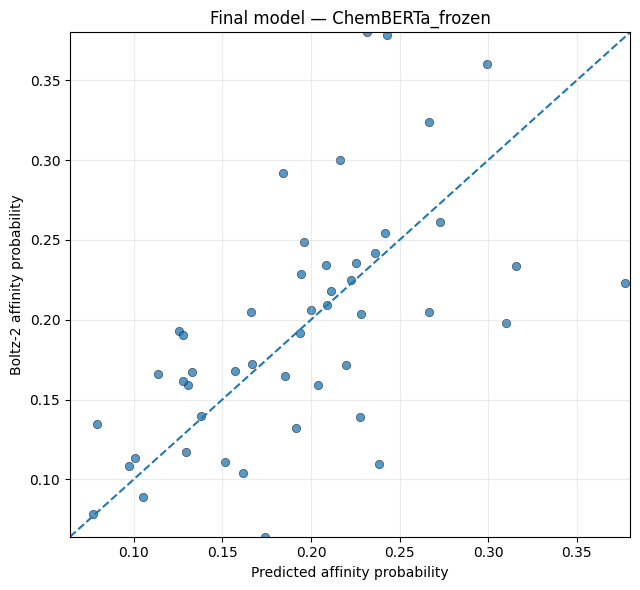

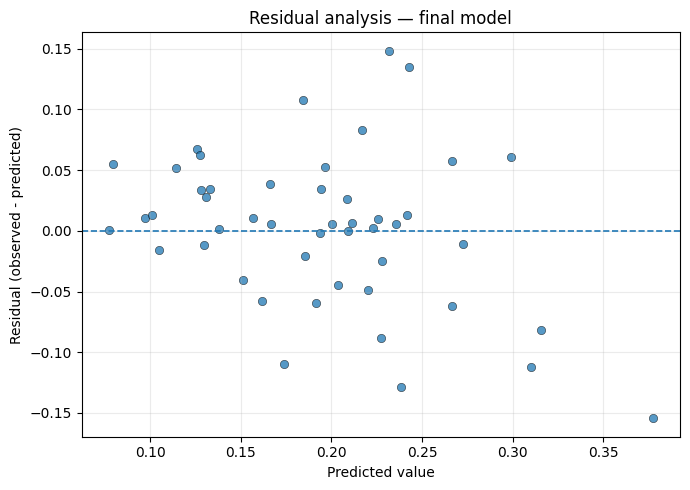

In [31]:
plot_predicted_vs_real(
    yw_test,
    pred_final,
    title=f"Final model — {winner_probability}",
    x_label="Predicted affinity probability",
    y_label="Boltz-2 affinity probability"
)

residuals = yw_test - pred_final

plt.figure(figsize=(7, 5))
plt.scatter(pred_final, residuals, alpha=0.75, edgecolor="black", linewidth=0.4)
plt.axhline(0, linestyle="--", linewidth=1.2)
plt.xlabel("Predicted value")
plt.ylabel("Residual (observed - predicted)")
plt.title("Residual analysis — final model")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

pd.DataFrame([final_metrics]).to_csv(
    OUTPUT_DIR / "final_model_metrics.csv",
    index=False
)

# Curva de aprendizado

A curva é usada para verificar overfitting. O modelo salvo corresponde ao menor erro de validação, e não à última época executada.

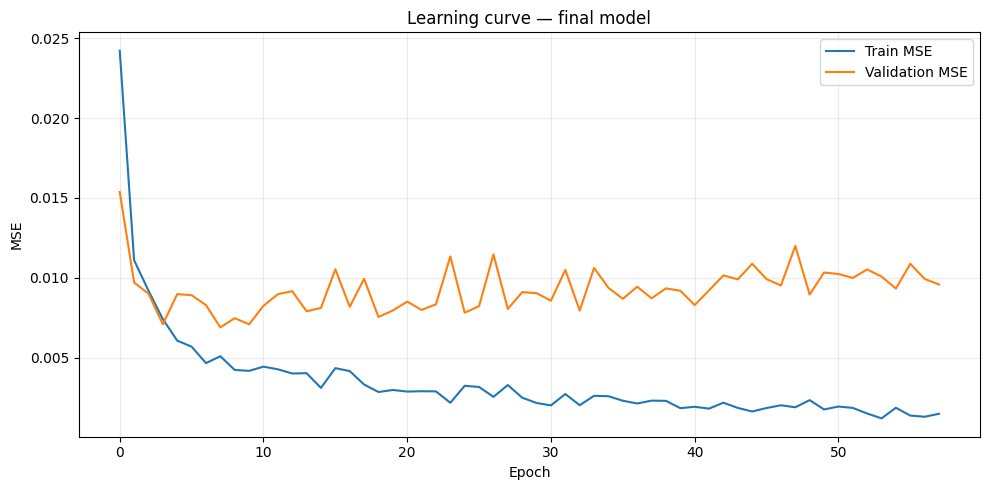

In [32]:
plt.figure(figsize=(10, 5))
plt.plot(history_final["train"], label="Train MSE")
plt.plot(history_final["val"], label="Validation MSE")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Learning curve — final model")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# Avaliação de ranking

Para a utilização posterior em screening, avaliamos explicitamente se as moléculas bem classificadas pelo Boltz-2 tendem a permanecer bem classificadas pelo modelo. Calculamos Spearman no teste e, opcionalmente, métricas Top-K.

In [33]:
ranking_df = pd.DataFrame({
    "observed": yw_test,
    "predicted": pred_final,
})

ranking_df["rank_observed"] = ranking_df["observed"].rank(
    ascending=False,
    method="first"
)
ranking_df["rank_predicted"] = ranking_df["predicted"].rank(
    ascending=False,
    method="first"
)

spearman = spearmanr(
    ranking_df["observed"],
    ranking_df["predicted"]
).statistic

print(f"Spearman rho: {spearman:.4f}")

def recall_at_k(y_true, y_pred, k=20):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    true_top = set(np.argsort(y_true)[::-1][:k])
    pred_top = set(np.argsort(y_pred)[::-1][:k])

    return len(true_top & pred_top) / len(true_top)

for k in [5, 10, 20, 50]:
    print(
        f"Recall@{k}: "
        f"{recall_at_k(yw_test, pred_final, k):.3f}"
    )

Spearman rho: 0.6702
Recall@5: 0.200
Recall@10: 0.500
Recall@20: 0.700
Recall@50: 1.000


# Salvamento do modelo

Esta etapa é importante porque este arquivo será a ponte para a segunda etapa do projeto.

Salvamos:
- pesos da FC-NN;
- scaler;
- configuração do modelo;
- métricas;
- índices dos conjuntos;
- embeddings, quando desejado.

A etapa posterior poderá carregar exatamente o mesmo modelo sem novo treinamento.

In [34]:
import joblib

MODEL_PATH = OUTPUT_DIR / "final_screening_mlp.pt"
SCALER_PATH = OUTPUT_DIR / "final_screening_scaler.pkl"
CONFIG_PATH = OUTPUT_DIR / "final_screening_config.json"
TEST_PRED_PATH = OUTPUT_DIR / "final_screening_test_predictions.csv"

torch.save(best_model.state_dict(), MODEL_PATH)

if winner_probability == "ChemBERTa_frozen":
    winning_scaler = embed_scaler
elif winner_probability == "RDKit":
    winning_scaler = rdkit_scaler
else:
    winning_scaler = None

if winning_scaler is not None:
    joblib.dump(winning_scaler, SCALER_PATH)

config = {
    "seed": SEED,
    "device": str(DEVICE),
    "chemberta_name": CHEMBERTA_NAME,
    "max_length": MAX_LENGTH,
    "target": "affinity_probability_binary",
    "winner_initial_representation": winner_probability,
    "best_optuna_value": float(study.best_value),
    "best_params": study.best_params,
    "metrics": final_metrics,
}

with open(CONFIG_PATH, "w", encoding="utf-8") as f:
    json.dump(config, f, indent=2, default=float)

pd.DataFrame({
    "y_observed": yw_test,
    "y_predicted": pred_final
}).to_csv(TEST_PRED_PATH, index=False)

print("Saved:")
for p in [MODEL_PATH, SCALER_PATH, CONFIG_PATH, TEST_PRED_PATH]:
    if p.exists():
        print(" -", p)

Saved:
 - results_approach_I\final_screening_mlp.pt
 - results_approach_I\final_screening_scaler.pkl
 - results_approach_I\final_screening_config.json
 - results_approach_I\final_screening_test_predictions.csv
